In [1]:
# @title Import packages for plotting and creating graphics
import json
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

# Graphics and plotting.
# print("Installing mediapy:")
# !command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
# !pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

In [2]:
# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

In [3]:
#@title Import The Playground

from mujoco_playground import wrapper
from mujoco_playground import registry

from etils import epath
from mujoco_playground._src import mjx_env
import mujoco.viewer

In [4]:
from mujoco_playground.config import locomotion_params

In [5]:
env_name = 'HunterJoystick'
_PLAY_ONLY = False

# New Customer pose
#1st
# _LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250911-215243/checkpoints" 
# _LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250911-234332/checkpoints" 
# _LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250912-092143/checkpoints" 
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250912-143941/checkpoints"

#2nd (2 phases)
# _LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250912-230847/checkpoints"
# _LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250913-012030/checkpoints"
# _LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250913-092212/checkpoints"
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250913-121843/checkpoints"


#3rd (3 phases)
# _LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250913-153303/checkpoints"
# _LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250913-221635//checkpoints"

#4th
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250914-093220/checkpoints" #Current best standing
# _LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250915-004945/checkpoints"
# _LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250915-155229/checkpoints"

#5th
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250915-191549/checkpoints"
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250915-210605/checkpoints"
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250915-220823/checkpoints"
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250915-234448/checkpoints"#Current best walking
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250916-162919/checkpoints"
 
#6th reduced obs - walking
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250918-001748/checkpoints"

#7th reduced obs - standing
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250918-213202/checkpoints"
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250919-001331/checkpoints"

#7th reduced obs - standing
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20250919-194821/checkpoints"

#8th reduced action_scale 0.5
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20251004-165226/checkpoints"
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20251005-004319/checkpoints"
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20251005-172059/checkpoints"

# action_scale 0.7
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20251005-191912/checkpoints"
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20251006-001607/checkpoints"
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20251006-172917/checkpoints"
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20251007-002449/checkpoints"


# # action_scale 0.9
# _LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20251006-093259/checkpoints"
# _LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20251006-121742/checkpoints"

# action_scale 1.0 with action_rate -0.5 + randomizer
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20251008-004211/checkpoints"
_LOAD_CHECKPOINT_PATH = "/media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20251008-083058/checkpoints"

env = registry.load(env_name)
env_cfg = registry.get_default_config(env_name)
ppo_params = locomotion_params.brax_ppo_config(env_name)

In [6]:
env_cfg

action_repeat: 1
action_scale: 1.0
command_config:
  ang_vel_threshold: 0.1
  ang_vel_yaw:
  - -0.0
  - 0.0
  lin_vel_threshold: 0.1
  lin_vel_x:
  - -0.0
  - 0.0
  lin_vel_y:
  - -0.0
  - 0.0
ctrl_dt: 0.02
early_termination: true
episode_length: 1000
foot_height:
- 0.15
- 0.6
gait_frequency:
- 0.0
- 0.5
gaits:
- walk
- stand
history_len: 1
impl: jax
nconmax: 8192
njmax: 42
obs_noise:
  level: 1.0
  scales:
    gravity: 0.05
    gyro: 0.2
    joint_pos: 0.01
    joint_vel: 1.5
push_config:
  enable: true
  interval_range:
  - 5.0
  - 10.0
  magnitude_range:
  - 0.1
  - 1.0
reward_config:
  scales:
    action_rate: -0.5
    ang_vel_xy: -0.0
    feet_air_time: 2.0
    feet_clearance: -1.0
    feet_contact: 0.5
    feet_distance: -0.0
    feet_phase: 3.0
    foot_slip: -0.1
    lin_vel_z: -5.0
    orientation: -2.0
    pose: -1.0
    stand_still: 4.0
    tracking_ang_vel: 0.75
    tracking_lin_vel: 3.5
  tracking_sigma: 0.5
sim_dt: 0.002

In [7]:
## For inference
if _PLAY_ONLY:
    ppo_params["num_timesteps"] = 0
else:
    ppo_params["num_timesteps"]= 100000000
    # ppo_params["num_timesteps"]= 200000000
    
    # ppo_params["num_timesteps"]= 150000000

In [8]:
ppo_params

action_repeat: 1
batch_size: 256
discounting: 0.97
entropy_cost: 0.01
episode_length: 1000
learning_rate: 0.0003
max_grad_norm: 1.0
network_factory:
  policy_hidden_layer_sizes: !!python/tuple
  - 128
  - 128
  - 128
  - 128
  policy_obs_key: state
  value_hidden_layer_sizes: !!python/tuple
  - 256
  - 256
  - 256
  - 256
  - 256
  value_obs_key: state
normalize_observations: true
num_envs: 8192
num_evals: 10
num_minibatches: 32
num_timesteps: 100000000
num_updates_per_batch: 4
reward_scaling: 1.0
unroll_length: 20

In [9]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]

def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

randomizer = registry.get_domain_randomizer(env_name)
ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **ppo_params.network_factory
  )

# Handle checkpoint loading
if _LOAD_CHECKPOINT_PATH is not None:
    # Convert to absolute path
    ckpt_path = epath.Path(_LOAD_CHECKPOINT_PATH).resolve()
    if ckpt_path.is_dir():
      latest_ckpts = list(ckpt_path.glob("*"))
      latest_ckpts = [ckpt for ckpt in latest_ckpts if ckpt.is_dir()]
      latest_ckpts.sort(key=lambda x: int(x.name))
      latest_ckpt = latest_ckpts[-1]
      restore_checkpoint_path = latest_ckpt
      print(f"Restoring from: {restore_checkpoint_path}")
    else:
      restore_checkpoint_path = ckpt_path
      print(f"Restoring from checkpoint: {restore_checkpoint_path}")
else:
    print("No checkpoint path provided, not restoring from checkpoint")
    restore_checkpoint_path = None

if not _PLAY_ONLY:
    # Generate unique experiment name
    now = datetime.now()
    timestamp = now.strftime("%Y%m%d-%H%M%S")
    exp_name = f"{env_name}-{timestamp}"
    print(f"Experiment name: {exp_name}")
    
    # Set up logging directory
    logdir = epath.Path("logs").resolve() / exp_name
    logdir.mkdir(parents=True, exist_ok=True)
    print(f"Logs are being stored in: {logdir}")
    
    # Set up checkpoint directory
    ckpt_path = logdir / "checkpoints"
    ckpt_path.mkdir(parents=True, exist_ok=True)
    print(f"Checkpoint path: {ckpt_path}")

    with open(ckpt_path / "config.json", "w", encoding="utf-8") as fp:
      json.dump(env_cfg.to_dict(), fp, indent=4)
else:
    ckpt_path = None

train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params),
    network_factory=network_factory,
    save_checkpoint_path=ckpt_path,
    restore_checkpoint_path=restore_checkpoint_path,
    randomization_fn=randomizer,
    progress_fn=progress
)

Restoring from: /media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20251008-083058/checkpoints/000100270080
Experiment name: HunterJoystick-20251008-142420
Logs are being stored in: /media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20251008-142420
Checkpoint path: /media/chikazoe/HDD6TB/Pham/8X-MujocoPG/mujoco_playground/logs/HunterJoystick-20251008-142420/checkpoints


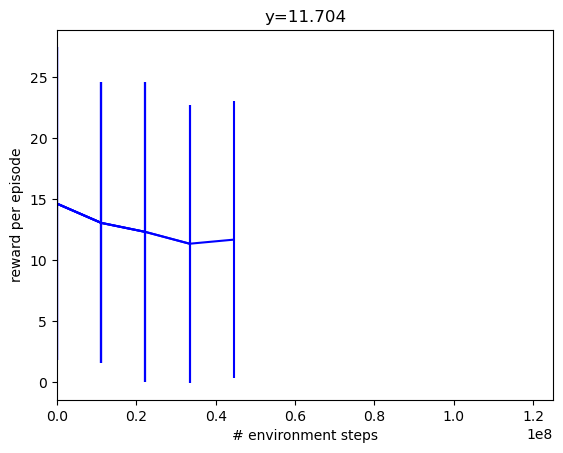

In [ ]:
make_inference_fn, params, metrics = train_fn(
    environment=env,
    eval_env=registry.load(env_name, config=env_cfg),
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
if len(times) > 1:
    print(f"time to jit: {times[1] - times[0]}")
    print(f"time to train: {times[-1] - times[1]}")

In [ ]:
#Adding push for test
#@title Rollout and Render

from mujoco_playground._src.gait import draw_joystick_command
import csv

env = registry.load(env_name)
eval_env = registry.load(env_name)
jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

rng = jax.random.PRNGKey(1)

rollout = []
modify_scene_fns = []

phase_dt = 2 * jp.pi * eval_env.dt * 1.5
phase = jp.array([0, jp.pi])
# phase = jp.array([0, 0.0])


log_push = []

push_step = 100  # When to apply the push
push_force_x = jp.array([-10.0, 0.0, 0.0])  # Newtons in -X direction
push_force_y = jp.array([0.0, 10.0, 0.0])  # Newtons in +Y direction
push_duration = 10  # How many steps the push lasts

body_id = eval_env.mj_model.body("base_link").id

def draw_force_arrow(scene: mujoco.MjvScene, data: mujoco.MjData):
    body_pos = data.xpos[body_id]
    applied_force = np.array(data.xfrc_applied[body_id][:3])

    force_magnitude = np.linalg.norm(applied_force)
    if force_magnitude < 1e-3:
        return

    # Visualization scale: adjust this value to your preference
    visualization_scale = 0.02
    arrow_length = force_magnitude * visualization_scale

    # Direction of the force
    arrow_dir = applied_force / force_magnitude

    # Orientation matrix (Z axis → arrow_dir)
    z_axis = np.array([0, 0, 1])
    if np.allclose(arrow_dir, z_axis) or np.allclose(arrow_dir, -z_axis):
        rot_mat = np.eye(3)
    else:
        v = np.cross(z_axis, arrow_dir)
        s = np.linalg.norm(v)
        c = np.dot(z_axis, arrow_dir)
        vx = np.array([
            [0, -v[2], v[1]],
            [v[2], 0, -v[0]],
            [-v[1], v[0], 0]
        ])
        rot_mat = np.eye(3) + vx + vx @ vx * ((1 - c) / (s**2 + 1e-8))

    geom_id = scene.ngeom
    if geom_id >= len(scene.geoms):
        return

    # Create a new geom object and add it to the scene
    geom = scene.geoms[geom_id]
    
    # Arrow geom type
    geom.type = mujoco.mjtGeom.mjGEOM_ARROW
    
    # Set the geom size: [shaft_radius, head_radius, arrow_length]
    geom.size[:] = [0.01, 0.02, arrow_length]
    
    # Position the geom at the body and orient it
    geom.pos[:] = body_pos
    geom.mat[:] = rot_mat

    geom.rgba[:] = [1, 0, 0, 1]
    scene.ngeom += 1

# Log eval action to csv
joint_names = []
for i in range(env._mj_model.nu):
  name = mujoco.mj_id2name(env._mj_model, mujoco.mjtObj.mjOBJ_ACTUATOR, i)
  print(i, name)
  joint_names.append(name)
csv_header = ["steps"] + joint_names

for j in range(1):
  print(f"episode {j}")
  state = jit_reset(rng)
  state.info["phase_dt"] = phase_dt
  state.info["phase"] = phase

  with open("9_7_1_actions_log.csv", mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(csv_header)
    step = 0
      
    for i in range(env_cfg.episode_length):
        act_rng, rng = jax.random.split(rng)
        ctrl, _ = jit_inference_fn(state.obs, act_rng)
        print(state.obs)
    
        data = state.data
        if push_step <= i < push_step + push_duration:
            # Create a force vector (6D: force + torque)
            force = jp.concatenate([push_force_x, jp.zeros(3)])  # No torque
            data = data.replace(
                xfrc_applied=data.xfrc_applied.at[body_id].set(force)
            )
        elif push_step*2 <= i < push_step*2 + push_duration:
            # Create a force vector (6D: force + torque)
            force = jp.concatenate([push_force_y, jp.zeros(3)])  # No torque
            data = data.replace(
                xfrc_applied=data.xfrc_applied.at[body_id].set(force)
            )
        else:
            # No force
            data = data.replace(
                xfrc_applied=data.xfrc_applied.at[body_id].set(jp.zeros(6))
            )
          
        state = state.replace(data=data)
          
        state = jit_step(state, ctrl)
        # if state.done:
        #   break
        # state.info["command"] = command
        rollout.append(state)
        step += 1
        
        # Log step + action values
        writer.writerow([step] + list(ctrl))
    
        modify_scene_fns.append(
            functools.partial(
                draw_force_arrow, 
                data=state.data
            )
        )


render_every = 1
fps = 1.0 / eval_env.dt / render_every
print(f"fps: {fps}")
traj = rollout[::render_every]
mod_fns = modify_scene_fns[::render_every]

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = False

frames = eval_env.render(
    traj,
    camera="track",
    scene_option=scene_option,
    width=640,
    height=480, 
    modify_scene_fns=mod_fns,
)
media.show_video(frames, fps=fps, loop=False)
media.write_video("./9_7_hunter_joystick_inference_CustomerPose_wPush_x-10N_Y+10N_scale1.0.mp4", frames, fps=fps, qp=18)

In [ ]:
eval_env = registry.load(env_name)
eval_env.dt *100

In [ ]:
# frames = eval_env.render(
#     traj,
#     camera="track",
#     scene_option=scene_option,
#     width=640,
#     height=480, 
#     modify_scene_fns=mod_fns,
# )
# media.show_video(frames, fps=fps, loop=False)
# media.write_video("./8_1_hunter_joystick_inference_CustomerPose_wPush_x-50N_Y+40N_track.mp4", frames, fps=fps, qp=18)

In [ ]:
# # Adding command for test
# #@title Rollout and Render
# from mujoco_playground._src.gait import draw_joystick_command

# env = registry.load(env_name)
# eval_env = registry.load(env_name)
# jit_reset = jax.jit(eval_env.reset)
# jit_step = jax.jit(eval_env.step)
# jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

# rng = jax.random.PRNGKey(1)

# rollout = []
# modify_scene_fns = []

# x_vel = -1.0  #@param {type: "number"}
# y_vel = 0.0  #@param {type: "number"}
# yaw_vel = 0.0  #@param {type: "number"}
# command = jp.array([x_vel, y_vel, yaw_vel])

# phase_dt = 2 * 0.5 * jp.pi * eval_env.dt * 1.5
# # phase = jp.array([0, 0.5* jp.pi])
# phase = jp.array([0, 0.0])

# duration = int(1/eval_env.dt)

# for j in range(1):
#   print(f"episode {j}")
#   state = jit_reset(rng)
#   state.info["phase_dt"] = phase_dt
#   state.info["phase"] = phase
#   for i in range(env_cfg.episode_length):
#     act_rng, rng = jax.random.split(rng)
#     ctrl, _ = jit_inference_fn(state.obs, act_rng)
#     state = jit_step(state, ctrl)
#     # if state.done:
#     #   break

   
#     if i in range(100,250):      
#         state.info["command"] = jp.array([1.0, 0.0, 0.0])        
#     elif i in range(350,500):
#         state.info["command"] = jp.array([0.0, -0.5, 0.0])
#     # elif i in range(105,130):
#     #     state.info["command"] = jp.array([0.0, 0.5, 0.0])
#     # elif i in range(155,180):
#     #     state.info["command"] = jp.array([1.0, 0.0, 0.0])
#     else:
#         state.info["command"] = jp.array([0.0, 0.0, 0.0])
        
#     rollout.append(state)

#     xyz = np.array(state.data.xpos[eval_env.mj_model.body("base_link").id])
#     xyz += np.array([0, 0.0, 0])
#     x_axis = state.data.xmat[eval_env.mj_model.body("base_link").id, 0]
#     yaw = -np.arctan2(x_axis[1], x_axis[0])
#     modify_scene_fns.append(
#         functools.partial(
#             draw_joystick_command,
#             cmd=state.info["command"],
#             xyz=xyz,
#             theta=yaw,
#             scl=np.linalg.norm(state.info["command"]),
#         )
#     )

# render_every = 1
# fps = 1.0 / eval_env.dt / render_every
# print(f"fps: {fps}")
# traj = rollout[::render_every]
# mod_fns = modify_scene_fns[::render_every]

# scene_option = mujoco.MjvOption()
# scene_option.geomgroup[2] = True
# scene_option.geomgroup[3] = False
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = False

# frames = eval_env.render(
#     traj,
#     # camera="track",
#     scene_option=scene_option,
#     width=640,
#     height=480,
#     modify_scene_fns=mod_fns,
# )
# media.show_video(frames, fps=fps, loop=False)
# media.write_video("./8_1_hunter_joystick_stair_wCMD.mp4", frames, fps=fps, qp=18)

In [ ]:
# frames = eval_env.render(
#     traj,
#     camera="track",
#     scene_option=scene_option,
#     width=640,
#     height=480,
#     modify_scene_fns=mod_fns,
# )
# media.show_video(frames, fps=fps, loop=False)
# media.write_video("./7_1_hunter_joystick_wCMD_track.mp4", frames, fps=fps, qp=18)